# 03. LoL 10분 승패예측 — 모델링 및 평가

최종 보고서 **3-4절, 5장, 6장**을 재현합니다.

주요 내용:

- Train / Validation / Test = 70 / 15 / 15, stratified hold-out
- Diff 중심 vs Total 중심 vs Total+Diff 표현 검증
- Logistic Regression / Random Forest / XGBoost Validation 비교
- Validation ROC-AUC 기준 최종 모델 선택
- 최종 Test 1회 평가
- 혼동행렬
- Threshold 분석
- Calibration / Brier score
- Permutation Importance
- 표준화 Logistic Regression 계수
- WardsPlaced Validation ablation
- 2,000회 Bootstrap 95% 신뢰구간
- 대표 오분류 사례 분석
- 최종 모델 Pipeline 저장

> **Test는 후보 선택이나 전처리 수정에 사용하지 않습니다.**


In [1]:
# 필요하면 한 번만 실행
# %pip install pandas numpy matplotlib scikit-learn xgboost joblib

from pathlib import Path
import json
import platform
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost

from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    brier_score_loss
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
TARGET = "blueWins"

RAW_CANDIDATES = [
    Path("high_diamond_ranked_10min(1).csv"),
    Path("high_diamond_ranked_10min.csv"),
    Path("/mnt/data/high_diamond_ranked_10min(1).csv"),
    Path("/mnt/data/high_diamond_ranked_10min.csv"),
]
RAW_PATH = next((p for p in RAW_CANDIDATES if p.exists()), None)

PRE_CANDIDATES = [
    Path("outputs/data/high_diamond_ranked_10min_preprocessed.csv"),
    Path("high_diamond_ranked_10min_preprocessed.csv"),
    Path("/mnt/data/outputs/data/high_diamond_ranked_10min_preprocessed.csv"),
    Path("/mnt/data/high_diamond_ranked_10min_preprocessed.csv"),
]
PRE_PATH = next((p for p in PRE_CANDIDATES if p.exists()), None)

if RAW_PATH is None:
    raise FileNotFoundError("원본 CSV를 찾을 수 없습니다.")
if PRE_PATH is None:
    raise FileNotFoundError("먼저 01 노트북을 실행해 전처리 CSV를 생성하세요.")

FIG_DIR = Path("outputs/figures_model")
TABLE_DIR = Path("outputs/tables_model")
MODEL_DIR = Path("outputs/models")
SPLIT_DIR = Path("outputs/splits")
for d in [FIG_DIR, TABLE_DIR, MODEL_DIR, SPLIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

raw = pd.read_csv(RAW_PATH)
df = pd.read_csv(PRE_PATH)

print("원본:", raw.shape)
print("전처리:", df.shape)
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)


원본: (9879, 40)
전처리: (9879, 22)
Python: 3.14.4
pandas: 3.0.5
numpy: 2.5.3
scikit-learn: 1.9.1
xgboost: 3.4.1


## 1. 최종 피처 및 데이터 분할


In [2]:
FINAL_FEATURES = [
    "blueWardsDestroyed","blueKills","blueAssists","blueFirstBlood",
    "blueDragons","blueHeralds","blueTowersDestroyed","blueAvgLevel",
    "blueTotalMinionsKilled","blueTotalJungleMinionsKilled",
    "blueGoldDiff","blueExperienceDiff",
    "redWardsDestroyed","redKills","redAssists","redDragons",
    "redHeralds","redTowersDestroyed","redAvgLevel",
    "redTotalMinionsKilled","redTotalJungleMinionsKilled",
]

assert df.columns.tolist() == FINAL_FEATURES + [TARGET]
assert df.shape == (9879, 22)

X = df[FINAL_FEATURES]
y = df[TARGET]

all_idx = np.arange(len(df))

idx_train, idx_temp = train_test_split(
    all_idx,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

idx_val, idx_test = train_test_split(
    idx_temp,
    test_size=0.50,
    stratify=y.iloc[idx_temp],
    random_state=RANDOM_STATE
)

X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
X_val, y_val = X.iloc[idx_val], y.iloc[idx_val]
X_test, y_test = X.iloc[idx_test], y.iloc[idx_test]

split_summary = pd.DataFrame({
    "rows": [len(idx_train), len(idx_val), len(idx_test)],
    "ratio_pct": [
        len(idx_train)/len(df)*100,
        len(idx_val)/len(df)*100,
        len(idx_test)/len(df)*100
    ],
    "blue_win_rate_pct": [
        y_train.mean()*100,
        y_val.mean()*100,
        y_test.mean()*100
    ]
}, index=["Train", "Validation", "Test"])

display(split_summary.round(3))

assert (len(idx_train), len(idx_val), len(idx_test)) == (6915, 1482, 1482)

# 필요하면 split 자체도 저장
for name, idx_part in [
    ("train", idx_train),
    ("validation", idx_val),
    ("test", idx_test)
]:
    temp = df.iloc[idx_part].copy()
    temp.insert(0, "row_index", idx_part)
    temp.to_csv(
        SPLIT_DIR / f"{name}_preprocessed.csv",
        index=False,
        encoding="utf-8-sig"
    )


,rows,ratio_pct,blue_win_rate_pct
Train,6915,69.997,49.906
Validation,1482,15.002,49.933
Test,1482,15.002,49.865


## 2. 피처 표현 방식 검증 — Diff vs Total

보고서의 **3-4절**을 재현합니다.
`Total`과 `Diff` 중 어느 표현을 사용할지는 Test가 아닌 **Validation**에서 비교합니다.


In [3]:
BASE_NON_ECON = [
    "blueWardsDestroyed","blueKills","blueAssists","blueFirstBlood",
    "blueDragons","blueHeralds","blueTowersDestroyed","blueAvgLevel",
    "blueTotalMinionsKilled","blueTotalJungleMinionsKilled",
    "redWardsDestroyed","redKills","redAssists","redDragons",
    "redHeralds","redTowersDestroyed","redAvgLevel",
    "redTotalMinionsKilled","redTotalJungleMinionsKilled",
]

REPRESENTATIONS = {
    "Diff 중심": BASE_NON_ECON + [
        "blueGoldDiff", "blueExperienceDiff"
    ],
    "Total 중심": BASE_NON_ECON + [
        "blueTotalGold", "redTotalGold",
        "blueTotalExperience", "redTotalExperience"
    ],
    "Total + Diff": BASE_NON_ECON + [
        "blueTotalGold", "redTotalGold",
        "blueTotalExperience", "redTotalExperience",
        "blueGoldDiff", "blueExperienceDiff"
    ],
}

def metrics_from_probability(y_true, proba, threshold=0.50):
    pred = (proba >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, proba),
    }

representation_rows = []

for name, cols in REPRESENTATIONS.items():
    m = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            random_state=RANDOM_STATE
        ))
    ])

    m.fit(raw.iloc[idx_train][cols], y_train)
    proba = m.predict_proba(raw.iloc[idx_val][cols])[:, 1]
    metrics = metrics_from_probability(y_val, proba)

    representation_rows.append({
        "configuration": name,
        "feature_count": len(cols),
        "Validation_Accuracy": metrics["Accuracy"],
        "Validation_F1": metrics["F1"],
        "Validation_ROC-AUC": metrics["ROC-AUC"],
    })

representation_results = pd.DataFrame(
    representation_rows
).set_index("configuration")

display(representation_results.round(6))
representation_results.to_csv(
    TABLE_DIR / "feature_representation_validation.csv",
    encoding="utf-8-sig"
)


,feature_count,Validation_Accuracy,Validation_F1,Validation_ROC-AUC
configuration,,,,
Diff 중심,21,0.717949,0.724638,0.800747
Total 중심,23,0.720648,0.726552,0.800408
Total + Diff,25,0.720648,0.726552,0.800382


## 3. 후보 모델 정의 및 Validation 비교

세 모델의 하이퍼파라미터는 보고서와 동일한 대표 설정으로 고정합니다.
광범위한 하이퍼파라미터 탐색이 아니므로 작은 차이를 알고리즘의 절대적 우열로 해석하지 않습니다.


,Fit_seconds,Val_Accuracy,Val_Precision,Val_Recall,Val_F1,Val_ROC-AUC
Model,,,,,,
Logistic Regression,0.043206,0.717949,0.706941,0.743243,0.724638,0.800747
Random Forest,1.174427,0.720648,0.713351,0.736486,0.724734,0.800319
XGBoost,1.268695,0.716599,0.707792,0.736486,0.721854,0.797549


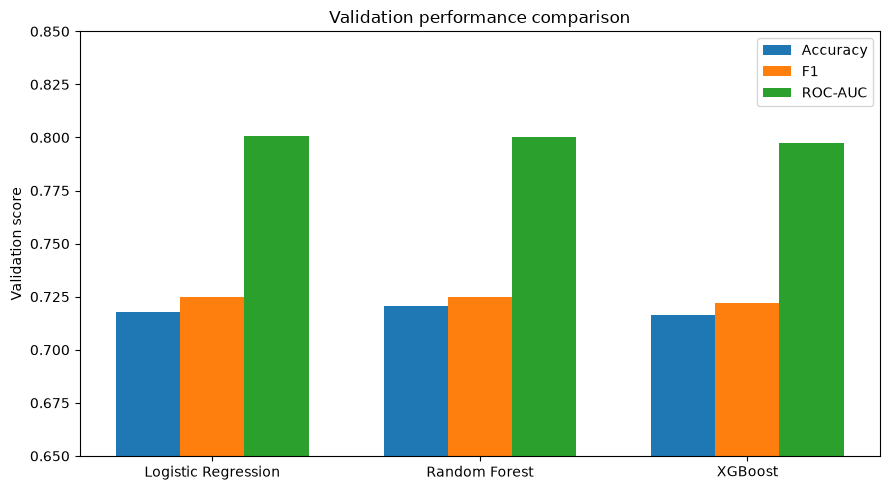

In [4]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=4,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_lambda=2,
        reg_alpha=0.05,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="logloss",
    )
}

validation_rows = []
trained_models = {}

for name, model in models.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start

    trained_models[name] = model

    val_proba = model.predict_proba(X_val)[:, 1]
    val_metrics = metrics_from_probability(y_val, val_proba)

    validation_rows.append({
        "Model": name,
        "Fit_seconds": fit_seconds,
        **{f"Val_{k}": v for k, v in val_metrics.items()}
    })

validation_results = pd.DataFrame(
    validation_rows
).set_index("Model")

display(validation_results.round(6))
validation_results.to_csv(
    TABLE_DIR / "validation_model_comparison.csv",
    encoding="utf-8-sig"
)

# 보고서 그림 5
metrics_to_plot = ["Val_Accuracy", "Val_F1", "Val_ROC-AUC"]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(validation_results.index))
width = 0.24

for i, metric in enumerate(metrics_to_plot):
    ax.bar(
        x + (i - 1) * width,
        validation_results[metric].values,
        width=width,
        label=metric.replace("Val_", "")
    )

ax.set_xticks(x)
ax.set_xticklabels(validation_results.index)
ax.set_ylim(0.65, 0.85)
ax.set_ylabel("Validation score")
ax.set_title("Validation performance comparison")
ax.legend()

fig.tight_layout()
fig.savefig(
    FIG_DIR / "05_validation_model_comparison.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()


## 4. 최종 모델 선택 후 Test 1회 평가

Validation ROC-AUC가 가장 높은 모델을 선택한 뒤에만 Test를 평가합니다.


In [5]:
best_name = validation_results["Val_ROC-AUC"].idxmax()
final_model = trained_models[best_name]

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.50).astype(int)
test_metrics = metrics_from_probability(y_test, test_proba)

print("최종 선택 모델:", best_name)
display(pd.Series(test_metrics, name="Test metric").to_frame())

test_metrics_df = pd.Series(test_metrics, name="value").to_frame()
test_metrics_df.to_csv(
    TABLE_DIR / "final_test_metrics.csv",
    encoding="utf-8-sig"
)

# 보고서 수치와 같은지 확인
assert best_name == "Logistic Regression"
assert round(test_metrics["ROC-AUC"], 4) == 0.8209
assert round(test_metrics["Accuracy"], 4) == 0.7348


최종 선택 모델: Logistic Regression


,Test metric
Accuracy,0.734818
Precision,0.736986
Recall,0.728011
F1,0.732471
ROC-AUC,0.820865


## 5. 그림 6 — Test 혼동행렬


confusion matrix:
[[551 192]
 [201 538]]


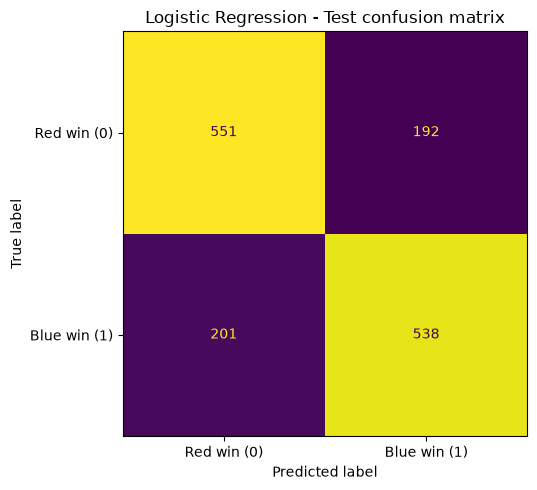

In [6]:
cm = confusion_matrix(y_test, test_pred)
print("confusion matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Red win (0)", "Blue win (1)"]
)
disp.plot(ax=ax, values_format="d", colorbar=False)
ax.set_title("Logistic Regression - Test confusion matrix")

fig.tight_layout()
fig.savefig(
    FIG_DIR / "06_confusion_matrix.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()

assert cm.tolist() == [[551, 192], [201, 538]]


## 6. Validation 임계값 분석

0.10~0.90을 0.02 간격으로 탐색합니다.
F1만 최대화하면 약 0.42가 유리하지만, 보고서에서는 Precision/Recall 균형을 고려하여 0.50을 유지합니다.


Validation F1 최대 임계값


,threshold,Accuracy,Precision,Recall,F1
16,0.42,0.709852,0.675339,0.806757,0.735222


threshold=0.50


,threshold,Accuracy,Precision,Recall,F1
20,0.5,0.717949,0.706941,0.743243,0.724638


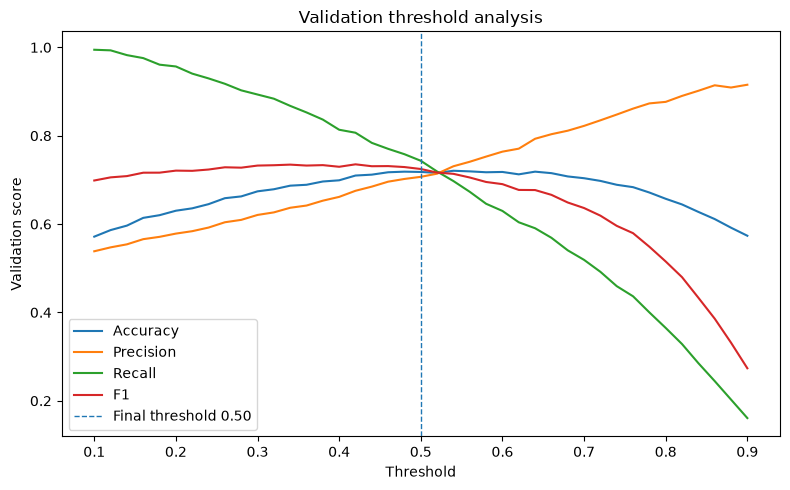

In [7]:
val_proba_final = final_model.predict_proba(X_val)[:, 1]
thresholds = np.round(np.arange(0.10, 0.901, 0.02), 2)

threshold_rows = []

for threshold in thresholds:
    pred = (val_proba_final >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
best_f1_row = threshold_df.loc[threshold_df["F1"].idxmax()]
default_row = threshold_df.loc[
    threshold_df["threshold"].eq(0.50)
].iloc[0]

print("Validation F1 최대 임계값")
display(best_f1_row.to_frame().T.round(6))

print("threshold=0.50")
display(default_row.to_frame().T.round(6))

threshold_df.to_csv(
    TABLE_DIR / "threshold_analysis_validation.csv",
    index=False,
    encoding="utf-8-sig"
)

fig, ax = plt.subplots(figsize=(8, 5))

for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    ax.plot(
        threshold_df["threshold"],
        threshold_df[metric],
        label=metric
    )

ax.axvline(0.50, linestyle="--", linewidth=1, label="Final threshold 0.50")
ax.set_xlabel("Threshold")
ax.set_ylabel("Validation score")
ax.set_title("Validation threshold analysis")
ax.legend()

fig.tight_layout()
fig.savefig(
    FIG_DIR / "threshold_analysis_validation.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()


## 7. 그림 7 — 확률 Calibration 및 Brier Score


Test Brier score: 0.172820


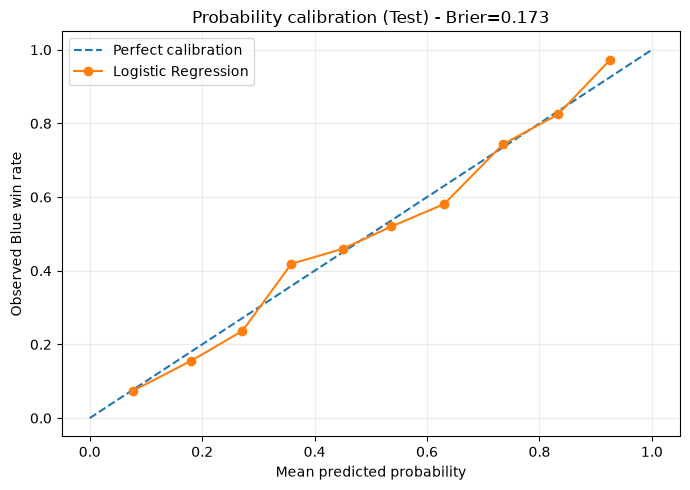

In [8]:
true_prob, pred_prob = calibration_curve(
    y_test,
    test_proba,
    n_bins=10,
    strategy="quantile"
)
brier = brier_score_loss(y_test, test_proba)

print(f"Test Brier score: {brier:.6f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
ax.plot(pred_prob, true_prob, marker="o", label=best_name)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed Blue win rate")
ax.set_title(f"Probability calibration (Test) - Brier={brier:.3f}")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIG_DIR / "07_probability_calibration.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()


## 8. 그림 8 — Permutation Importance

Test를 피처 중요도 판단에 재사용하지 않기 위해 **Validation ROC-AUC 기준**으로 계산합니다.
상관된 피처끼리는 중요도가 나뉘어 보일 수 있으므로 인과효과로 해석하지 않습니다.


,feature,importance_mean,importance_std
10,blueGoldDiff,0.253265,0.013262
11,blueExperienceDiff,0.031834,0.006170
15,redDragons,0.003336,0.001684
1,blueKills,0.001649,0.001375
4,blueDragons,0.001621,0.001958
19,redTotalMinionsKilled,0.001501,0.001014
17,redTowersDestroyed,0.001049,0.000559
8,blueTotalMinionsKilled,0.001036,0.000993
3,blueFirstBlood,0.000790,0.000405
20,redTotalJungleMinionsKilled,0.000683,0.000756


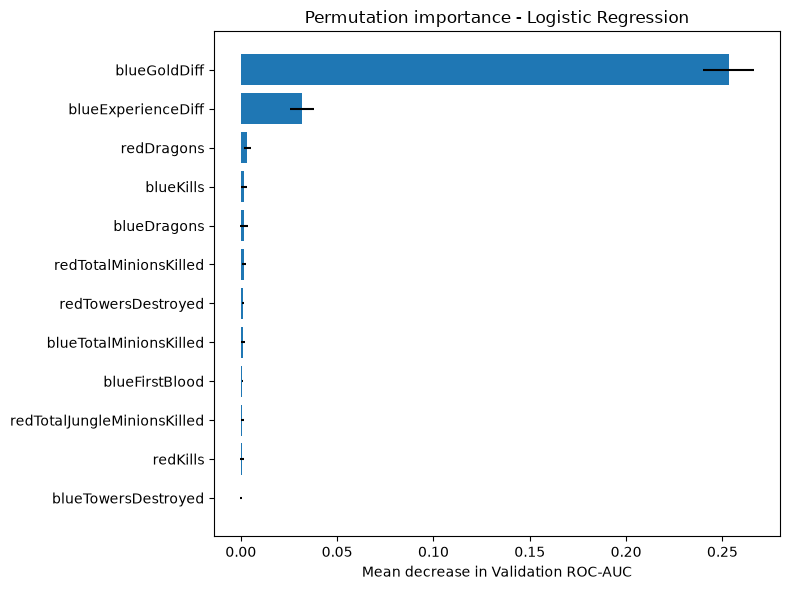

In [9]:
perm = permutation_importance(
    final_model,
    X_val,
    y_val,
    scoring="roc_auc",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": FINAL_FEATURES,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(15).round(6))

perm_df.to_csv(
    TABLE_DIR / "permutation_importance_validation.csv",
    index=False,
    encoding="utf-8-sig"
)

plot_df = perm_df.head(12).sort_values("importance_mean")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"]
)
ax.set_xlabel("Mean decrease in Validation ROC-AUC")
ax.set_title("Permutation importance - Logistic Regression")

fig.tight_layout()
fig.savefig(
    FIG_DIR / "08_permutation_importance_validation.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()


## 9. Logistic Regression 표준화 계수

계수는 다른 피처를 통제한 **조건부 관계**입니다.
최종 피처에도 높은 상관이 남아 있으므로 부호/크기를 독립적 효과나 인과관계로 해석하지 않습니다.


In [10]:
lr_pipeline = trained_models["Logistic Regression"]
coefficients = lr_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": FINAL_FEATURES,
    "standardized_coefficient": coefficients
})
coef_df["abs_coef"] = coef_df["standardized_coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

display(
    coef_df[["feature", "standardized_coefficient"]]
    .head(21)
    .round(6)
)

coef_df.to_csv(
    TABLE_DIR / "logistic_standardized_coefficients.csv",
    index=False,
    encoding="utf-8-sig"
)


,feature,standardized_coefficient
10,blueGoldDiff,1.321876
11,blueExperienceDiff,0.475234
4,blueDragons,0.179281
1,blueKills,-0.151966
15,redDragons,-0.149042
13,redKills,0.120346
19,redTotalMinionsKilled,0.118440
8,blueTotalMinionsKilled,-0.108883
14,redAssists,0.089449
17,redTowersDestroyed,0.071107


## 10. WardsPlaced Validation Ablation

`WardsPlaced` 제거는 **성능 향상 때문에 결정한 것이 아닙니다.**
먼저 데이터 품질과 해석 가능성 관점에서 제외한 뒤,
Validation ablation으로 제거에 따른 성능 손실이 큰지 사후 점검합니다.


In [11]:
features_with_wards = FINAL_FEATURES + [
    "blueWardsPlaced", "redWardsPlaced"
]

Xw_train = raw.iloc[idx_train][features_with_wards]
Xw_val = raw.iloc[idx_val][features_with_wards]

xgb_params = dict(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    reg_lambda=2,
    reg_alpha=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="logloss",
)

xgb_without = XGBClassifier(**xgb_params)
xgb_with = XGBClassifier(**xgb_params)

xgb_without.fit(X_train, y_train)
xgb_with.fit(Xw_train, y_train)

p_without = xgb_without.predict_proba(X_val)[:, 1]
p_with = xgb_with.predict_proba(Xw_val)[:, 1]

ablation = pd.DataFrame({
    "without_WardsPlaced": metrics_from_probability(y_val, p_without),
    "with_WardsPlaced": metrics_from_probability(y_val, p_with),
}).T

display(ablation.round(6))

delta_auc = (
    ablation.loc["without_WardsPlaced", "ROC-AUC"]
    - ablation.loc["with_WardsPlaced", "ROC-AUC"]
)

print(f"ROC-AUC 차이(without - with): {delta_auc:+.6f}")
print("보고서 해석: 약 0.001 수준의 매우 작은 차이로, 제거의 주 근거는 데이터 품질 판단입니다.")

ablation.to_csv(
    TABLE_DIR / "wardsplaced_ablation_validation.csv",
    encoding="utf-8-sig"
)


,Accuracy,Precision,Recall,F1,ROC-AUC
without_WardsPlaced,0.716599,0.707792,0.736486,0.721854,0.797549
with_WardsPlaced,0.712551,0.701799,0.737838,0.719368,0.797638


ROC-AUC 차이(without - with): -0.000089
보고서 해석: 약 0.001 수준의 매우 작은 차이로, 제거의 주 근거는 데이터 품질 판단입니다.


## 11. Test 성능 Bootstrap 95% 신뢰구간

최종 Test 예측을 2,000회 bootstrap resampling하여 점 추정치의 표본 변동성을 확인합니다.


In [12]:
rng = np.random.default_rng(RANDOM_STATE)
n_boot = 2000
indices = np.arange(len(y_test))
y_test_np = y_test.to_numpy()

boot_values = {
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": [],
    "ROC-AUC": [],
}

for _ in range(n_boot):
    sample_idx = rng.choice(
        indices,
        size=len(indices),
        replace=True
    )

    y_boot = y_test_np[sample_idx]
    p_boot = test_proba[sample_idx]

    # AUC 계산에는 두 클래스가 모두 필요
    if len(np.unique(y_boot)) < 2:
        continue

    pred_boot = (p_boot >= 0.50).astype(int)

    boot_values["Accuracy"].append(
        accuracy_score(y_boot, pred_boot)
    )
    boot_values["Precision"].append(
        precision_score(y_boot, pred_boot, zero_division=0)
    )
    boot_values["Recall"].append(
        recall_score(y_boot, pred_boot, zero_division=0)
    )
    boot_values["F1"].append(
        f1_score(y_boot, pred_boot, zero_division=0)
    )
    boot_values["ROC-AUC"].append(
        roc_auc_score(y_boot, p_boot)
    )

ci_rows = []

for metric, values in boot_values.items():
    low, high = np.quantile(values, [0.025, 0.975])

    ci_rows.append({
        "metric": metric,
        "point_estimate": test_metrics[metric],
        "CI95_low": low,
        "CI95_high": high,
    })

ci_df = pd.DataFrame(ci_rows).set_index("metric")
display(ci_df.round(6))

ci_df.to_csv(
    TABLE_DIR / "final_test_bootstrap_ci95.csv",
    encoding="utf-8-sig"
)


,point_estimate,CI95_low,CI95_high
metric,,,
Accuracy,0.734818,0.711201,0.757085
Precision,0.736986,0.703806,0.769127
Recall,0.728011,0.696286,0.760811
F1,0.732471,0.706036,0.758010
ROC-AUC,0.820865,0.799156,0.840153


## 12. 대표 오분류 사례 분석

보고서의 대표 FN/FP 사례를 재현합니다.
`gameId`는 모델 입력이 아니라 **사후 추적용 식별자**로만 사용합니다.


In [13]:
lookup = pd.DataFrame({
    "row_index": np.arange(len(raw)),
    "gameId": raw["gameId"].values
}).set_index("row_index")

error_df = pd.DataFrame({
    "row_index": idx_test,
    "actual": y_test.values,
    "predicted": test_pred,
    "p_blue_win": test_proba,
}, index=idx_test)

error_df["is_error"] = (
    error_df["actual"] != error_df["predicted"]
)

# 틀렸을 때 모델의 자신감
error_df["wrong_confidence"] = np.where(
    error_df["actual"] == 1,
    1 - error_df["p_blue_win"],
    error_df["p_blue_win"]
)

context_cols = [
    "blueGoldDiff", "blueExperienceDiff",
    "blueKills", "redKills",
    "blueDragons", "redDragons",
    "blueTotalMinionsKilled", "redTotalMinionsKilled"
]

errors = (
    error_df[error_df["is_error"]]
    .join(df[context_cols])
    .join(lookup[["gameId"]])
    .sort_values("wrong_confidence", ascending=False)
)

display(errors.head(10).round(5))

report_case_ids = [
    4499239181,
    4518384119,
    4448427323,
]

print("보고서 대표 사례:")
display(
    errors[errors["gameId"].isin(report_case_ids)]
    .round(5)
)

errors.to_csv(
    TABLE_DIR / "misclassified_test_cases.csv",
    index=False,
    encoding="utf-8-sig"
)


,row_index,actual,predicted,p_blue_win,is_error,wrong_confidence,blueGoldDiff,blueExperienceDiff,blueKills,redKills,blueDragons,redDragons,blueTotalMinionsKilled,redTotalMinionsKilled,gameId
4454,4454,1,0,0.02035,True,0.97965,-5976,-4619,4,14,0,1,186,264,4499239181
9112,9112,1,0,0.04784,True,0.95216,-4552,-4208,7,15,0,1,189,234,4518384119
1194,1194,0,1,0.94996,True,0.94996,4941,4702,15,3,0,0,261,190,4448427323
3343,3343,1,0,0.05006,True,0.94994,-4738,-2857,3,7,0,1,176,264,4479706373
4100,4100,1,0,0.05036,True,0.94964,-4903,-3146,4,17,0,1,184,204,4419367000
5898,5898,1,0,0.06562,True,0.93438,-3750,-3108,1,4,0,1,238,244,4464700538
8047,8047,0,1,0.92960,True,0.92960,3708,2901,12,4,1,0,225,203,4527042510
9028,9028,1,0,0.07635,True,0.92365,-3688,-2808,3,7,0,1,214,258,4511237975
4923,4923,1,0,0.08693,True,0.91307,-3401,-2179,4,12,0,1,218,219,4499732263
918,918,1,0,0.09954,True,0.90046,-3622,-1908,6,14,0,1,196,224,4424078266


보고서 대표 사례:


,row_index,actual,predicted,p_blue_win,is_error,wrong_confidence,blueGoldDiff,blueExperienceDiff,blueKills,redKills,blueDragons,redDragons,blueTotalMinionsKilled,redTotalMinionsKilled,gameId
4454,4454,1,0,0.02035,True,0.97965,-5976,-4619,4,14,0,1,186,264,4499239181
9112,9112,1,0,0.04784,True,0.95216,-4552,-4208,7,15,0,1,189,234,4518384119
1194,1194,0,1,0.94996,True,0.94996,4941,4702,15,3,0,0,261,190,4448427323


## 13. 최종 모델 및 메타데이터 저장

`StandardScaler`와 Logistic Regression을 한 Pipeline으로 저장합니다.


In [14]:
MODEL_PATH = MODEL_DIR / "final_logistic_regression_pipeline.joblib"
META_PATH = MODEL_DIR / "model_metadata.json"

joblib.dump(final_model, MODEL_PATH)

metadata = {
    "model_name": best_name,
    "target": TARGET,
    "features": FINAL_FEATURES,
    "threshold": 0.50,
    "random_state": RANDOM_STATE,
    "test_metrics": {
        k: float(v) for k, v in test_metrics.items()
    },
    "brier_score": float(brier),
    "versions": {
        "python": sys.version.split()[0],
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
        "xgboost": xgboost.__version__,
    }
}

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("모델 저장:", MODEL_PATH.resolve())
print("메타데이터:", META_PATH.resolve())


모델 저장: C:\Users\KTK\Desktop\LOL\outputs\models\final_logistic_regression_pipeline.joblib
메타데이터: C:\Users\KTK\Desktop\LOL\outputs\models\model_metadata.json


## 14. 최종 요약


In [15]:
print("=== 재현 결과 ===")
print("Train / Validation / Test:",
      len(idx_train), len(idx_val), len(idx_test))
print("최종 모델:", best_name)
print("Test Accuracy:", round(test_metrics["Accuracy"], 4))
print("Test Precision:", round(test_metrics["Precision"], 4))
print("Test Recall:", round(test_metrics["Recall"], 4))
print("Test F1:", round(test_metrics["F1"], 4))
print("Test ROC-AUC:", round(test_metrics["ROC-AUC"], 4))
print("Test Brier:", round(brier, 4))
print("Confusion Matrix:", cm.tolist())

print("\n생성 이미지:")
for p in sorted(FIG_DIR.glob("*.png")):
    print(" -", p.resolve())


=== 재현 결과 ===
Train / Validation / Test: 6915 1482 1482
최종 모델: Logistic Regression
Test Accuracy: 0.7348
Test Precision: 0.737
Test Recall: 0.728
Test F1: 0.7325
Test ROC-AUC: 0.8209
Test Brier: 0.1728
Confusion Matrix: [[551, 192], [201, 538]]

생성 이미지:
 - C:\Users\KTK\Desktop\LOL\outputs\figures_model\05_validation_model_comparison.png
 - C:\Users\KTK\Desktop\LOL\outputs\figures_model\06_confusion_matrix.png
 - C:\Users\KTK\Desktop\LOL\outputs\figures_model\07_probability_calibration.png
 - C:\Users\KTK\Desktop\LOL\outputs\figures_model\08_permutation_importance_validation.png
 - C:\Users\KTK\Desktop\LOL\outputs\figures_model\threshold_analysis_validation.png
